# Classifier work on the rig gathered digital dataset 

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os 
from tqdm import tqdm
DATA_PATH="/home/dexter/Documents/data/simulation"

## Import data

In [2]:
df = pd.read_csv(DATA_PATH+"/recordings.csv")
df.head()

,image_id,x,y,z,theta_x,theta_y,theta_z,speed,texture_id,marker_0_x,...,marker_145_z,marker_146_x,marker_146_y,marker_146_z,marker_147_x,marker_147_y,marker_147_z,marker_148_x,marker_148_y,marker_148_z
0,0,0.3,0.3,0.22,-1.570796,-1.570796,-1.570796,0.0,0,0.299999,...,0.225922,0.305141,0.384792,0.222959,0.305135,0.384794,0.217033,0.300005,0.385005,0.219993
1,1,0.3,0.3,0.21,-1.570796,-1.570796,-1.570796,0.0,0,0.299999,...,0.215906,0.305149,0.384795,0.212941,0.305140,0.384798,0.207009,0.300005,0.385008,0.209974
2,2,0.3,0.3,0.20,-1.570796,-1.570796,-1.570796,0.0,0,0.299999,...,0.205891,0.305156,0.384799,0.202922,0.305145,0.384802,0.196983,0.300004,0.385013,0.199953
3,3,0.3,0.3,0.19,-1.570796,-1.570796,-1.570796,0.0,0,0.299990,...,0.195876,0.305164,0.384803,0.192904,0.305150,0.384806,0.186958,0.300003,0.385018,0.189933
4,4,0.3,0.3,0.18,-1.570796,-1.570796,-1.570796,0.0,0,0.299872,...,0.185863,0.305175,0.384807,0.182881,0.305152,0.384811,0.176928,0.300002,0.385025,0.179914


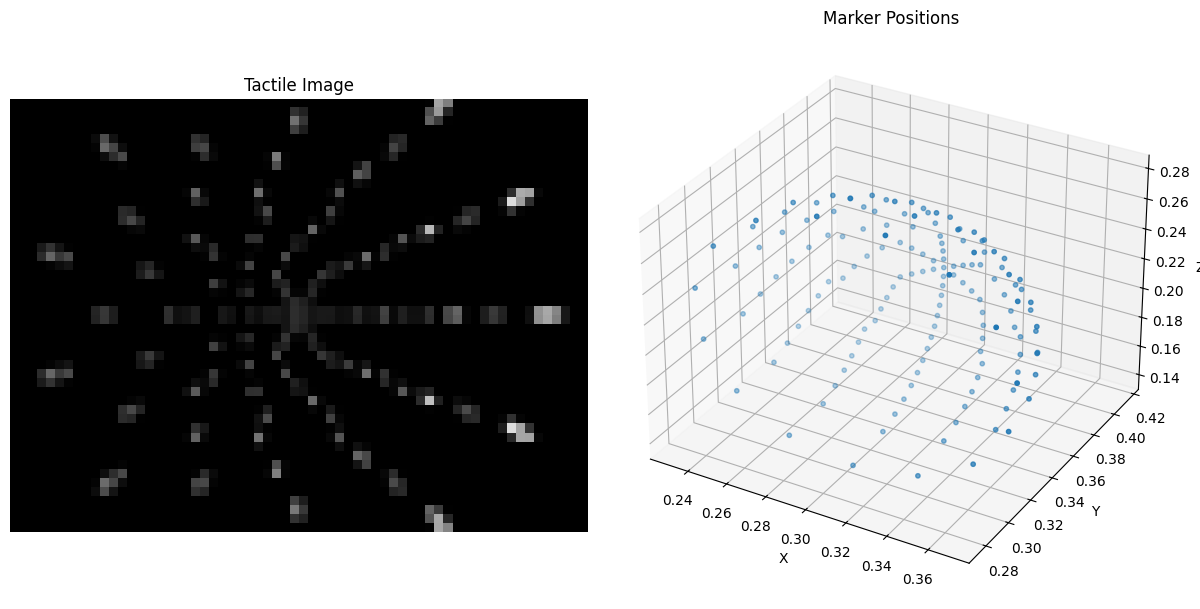

In [3]:
def get_entry_frame(image_id):
    row = df[df["image_id"] == image_id].iloc[0]

    # Find marker columns
    marker_cols = [
        col for col in df.columns 
        if col.startswith("marker_")
    ]

    # Extract marker values
    marker_values = row[marker_cols].values.astype(float)

    # Reshape into Nx3
    markers = marker_values.reshape(-1, 3)

    return markers

def plot_image_and_markers(image_path, markers):
    """
    Display tactile image alongside 3D marker positions.

    Args:
        image_path (str): Path to tactile image
        markers (np.ndarray): Nx3 array of marker positions
    """

    # Load image
    image = cv2.imread(image_path)

    # Convert BGR -> RGB for matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Create figure with two subplots
    fig = plt.figure(figsize=(12, 6))

    # Image subplot
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(image)
    ax1.set_title("Tactile Image")
    ax1.axis("off")

    # 3D marker subplot
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    x = markers[:, 0]
    y = markers[:, 1]
    z = markers[:, 2]

    ax2.scatter(x, y, z, s=10)

    ax2.set_title("Marker Positions")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")

    # Equal axis scaling
    max_range = np.ptp(markers, axis=0).max()

    mid_x = (x.max() + x.min()) / 2
    mid_y = (y.max() + y.min()) / 2
    mid_z = (z.max() + z.min()) / 2

    ax2.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
    ax2.set_ylim(mid_y - max_range/2, mid_y + max_range/2)
    ax2.set_zlim(mid_z - max_range/2, mid_z + max_range/2)

    plt.tight_layout()
    plt.show()

image_id=1
markers = get_entry_frame(image_id)
plot_image_and_markers(
    DATA_PATH+f"/images/{image_id}.png",
    markers
)

## Regression model

In [9]:

def load_tactile_dataset(image_folder, csv_path):
    """
    Loads tactile images and marker positions.

    Returns:
        X: numpy array of images
        y: numpy array of marker positions
    """

    df = pd.read_csv(csv_path)

    images = []
    markers = []

    # Loop through dataset entries
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Loading dataset"):

        image_id = int(row["image_id"])

        # Load image
        image_path = os.path.join(
            image_folder,
            f"{image_id}.png"
        )

        image = cv2.imread(image_path)

        # Normalise image
        image = image
        image = cv2.resize(
            image,
            (64, 64),
            interpolation=cv2.INTER_AREA
        )
        images.append(image)
        # Extract marker columns
        marker_cols = [
            c for c in df.columns
            if c.startswith("marker_")
        ]

        marker_values = row[marker_cols].values.astype(np.float16)

        # Convert flat vector into Nx3
        marker_positions = marker_values.reshape(-1,3)

        markers.append(marker_positions)


    X = np.array(images).astype(np.float16) / 255.0
    y = np.array(markers)

    return X, y
X, y = load_tactile_dataset(
    DATA_PATH+"/images",
    DATA_PATH+"/recordings.csv"
)

print(X.shape)
print(y.shape)

Loading dataset: 100%|██████████| 11250/11250 [00:12<00:00, 907.23it/s]


(11250, 64, 64, 3)
(11250, 149, 3)


In [5]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [8]:
X.shape

(3600, 38400)

In [ ]:
X=X.reshape((len(X),-1))
y=y.reshape((len(y),-1))
av_acc=[]
av_acc_train=[]
for i in range(20):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=np.random.randint(0,100)
    )
    model = Ridge(alpha=150)

    model.fit(
        X_train,
        y_train
    )
    y_pred = model.predict(X_test)
    
    av_acc.append(mean_squared_error(y_test, y_pred))
    y_pred = model.predict(X_train)

    av_acc_train.append(mean_squared_error(y_train, y_pred))
av_acc=np.array(av_acc)
av_acc_train=np.array(av_acc_train)
print(av_acc.mean(),av_acc_train.mean())

KeyboardInterrupt: 

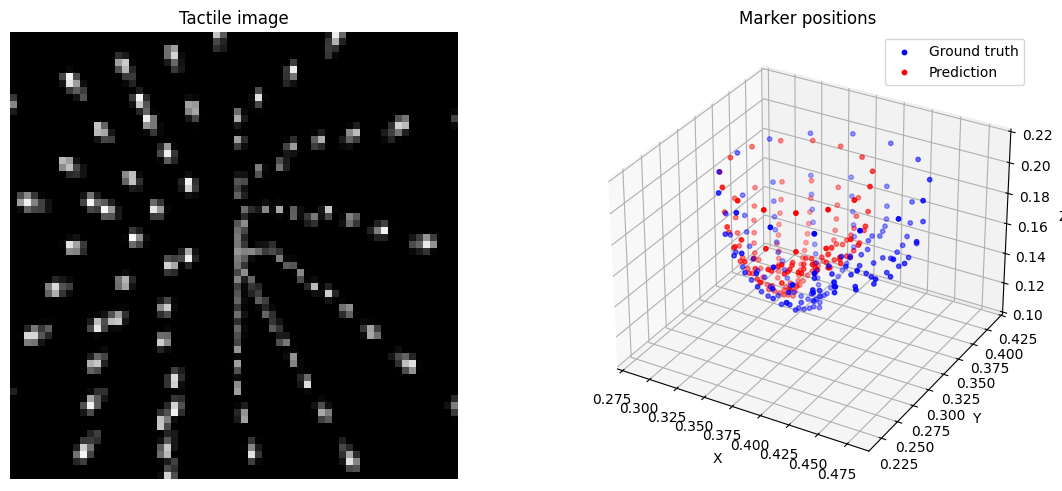

In [ ]:
pred=model.predict(X_test)
idx=np.random.randint(0,len(X_test)-1)
im=(X_test[idx].reshape((64,64,3))*255).astype(np.uint8)
points=y_test[idx].reshape((149,3))
points_hat=pred[idx].reshape((149,3))

fig = plt.figure(figsize=(12,5))


# ---- image ----
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(im)
ax1.set_title("Tactile image")
ax1.axis("off")


# ---- 3D points ----
ax2 = fig.add_subplot(1,2,2, projection="3d")

# ground truth
ax2.scatter(
    points[:,0],
    points[:,1],
    points[:,2],
    c="blue",
    s=10,
    label="Ground truth"
)

# prediction
ax2.scatter(
    points_hat[:,0],
    points_hat[:,1],
    points_hat[:,2],
    c="red",
    s=10,
    label="Prediction"
)


ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

ax2.set_title("Marker positions")
ax2.legend()

plt.tight_layout()
plt.show()

## Transfer model